### **EXERCÍCIO PRÁTICO**

Você recebeu um conjunto de dados contendo informações sobre a idade, anos de experiência e salário de um grupo de profissionais. O objetivo é treinar um modelo de regressão linear para prever o salário com base na idade e nos anos de experiência, e visualizar a correlação entre essas variáveis.

**Passos do Exercício**

1. Treinamento do Modelo:

+ Utilize PandasAI para treinar um modelo de regressão linear que preveja o salário com base na idade e anos de experiência.

2. Previsão para Novos Dados:

+ Crie um novo conjunto de dados com valores de idade e anos de experiência que não existem no conjunto de dados original e use PandasAI para prever os salários para esses novos dados.

3. Visualização dos Resultados:

+ Plote a matriz de correlação entre idade, anos de experiência e salário.
+ Crie um gráfico de dispersão 3D que mostre a relação entre idade, anos de experiência e salário, diferenciando em cores os novos dados previstos dos dados originais.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

## 📓 Criar o dataset

In [3]:
# Criar DataFrame de exemplo
data = { 'idade': [25, 32, 47, 51, 62, 38, 29, 45, 56, 40, 35, 31, 28, 50, 48],
         'anos_experiencia': [2, 5, 20, 25, 30, 10, 4, 18, 28, 12, 7, 5, 3, 22, 19],
         'salario': [35000, 48000, 80000, 90000, 120000, 55000, 42000, 75000, 110000, 60000, 52000, 47000, 40000, 85000, 82000] }
df = pd.DataFrame(data)

print(df.head())

   idade  anos_experiencia  salario
0     25                 2    35000
1     32                 5    48000
2     47                20    80000
3     51                25    90000
4     62                30   120000


## 📓 Treinar modelo de regressão

In [5]:
X = df[['idade', 'anos_experiencia']]
y = df['salario']

model = LinearRegression()
model.fit(X, y)

print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)

Coeficientes: [1572.68281412  860.07162386]
Intercepto: -8664.02248835162


## 📓 Criar novos dados para previsão

In [6]:
novos_dados = pd.DataFrame({
    'idade': [30, 42, 55],
    'anos_experiencia': [6, 15, 27]
})

novos_dados

,idade,anos_experiencia
0,30,6
1,42,15
2,55,27


## 📓 Prever salários

In [7]:
novos_dados['salario_previsto'] = model.predict(novos_dados)

novos_dados

,idade,anos_experiencia,salario_previsto
0,30,6,43676.891679
1,42,15,70289.730063
2,55,27,101055.466133


## 📓 Matriz de correlação

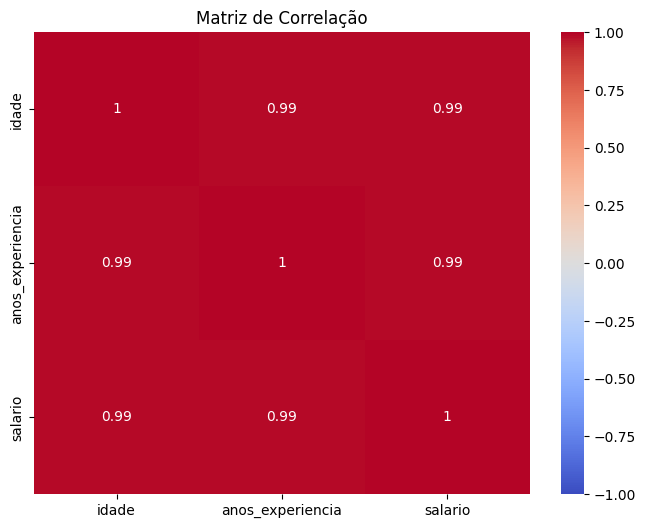

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Matriz de Correlação")
plt.show()

## 📓 Juntar dados originais e previstos

In [9]:
novos_dados_renomeado = novos_dados.rename(columns={'salario_previsto':'salario'})

df_updated = pd.concat([df, novos_dados_renomeado], ignore_index=True)

df_updated

,idade,anos_experiencia,salario
0,25,2,35000.000000
1,32,5,48000.000000
2,47,20,80000.000000
3,51,25,90000.000000
4,62,30,120000.000000
5,38,10,55000.000000
6,29,4,42000.000000
7,45,18,75000.000000
8,56,28,110000.000000
9,40,12,60000.000000


## 📓 Gráfico 3D

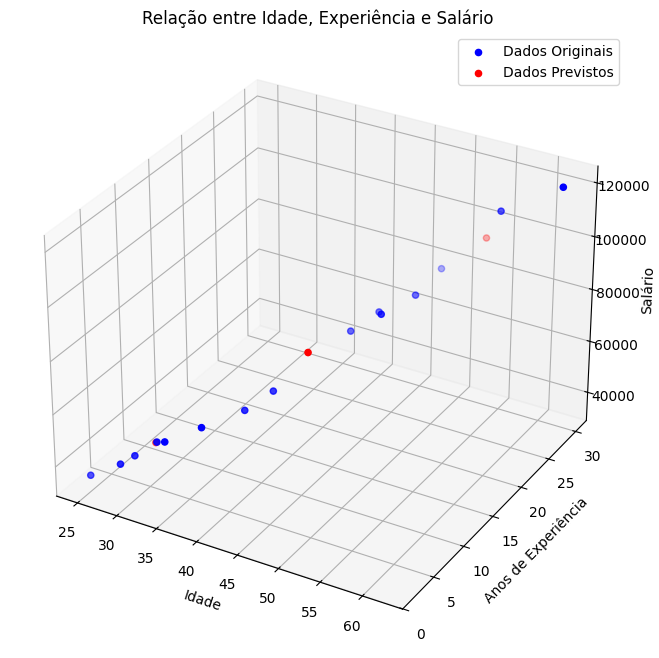

In [10]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# dados originais
ax.scatter(
    df['idade'],
    df['anos_experiencia'],
    df['salario'],
    color='blue',
    label='Dados Originais'
)

# dados previstos
ax.scatter(
    novos_dados['idade'],
    novos_dados['anos_experiencia'],
    novos_dados['salario_previsto'],
    color='red',
    label='Dados Previstos'
)

ax.set_xlabel('Idade')
ax.set_ylabel('Anos de Experiência')
ax.set_zlabel('Salário')

ax.set_title("Relação entre Idade, Experiência e Salário")

ax.legend()

plt.show()

## 📈 Escala do R²

O valor vai de 0 a 1.

| R² |	Significado |
| ---| --- |
| 0	| o modelo não explica nada |
| 0.3	| explica 30% da variação |
| 0.6	| explica 60% |
| 0.9	| explica muito bem |
| 1	| modelo perfeito |

Exemplo:
Se o modelo retornar:
```
R² = 0.85
```
significa:

> 85% da variação do salário pode ser explicada por idade e anos de experiência.

Os **15% restantes** são coisas que o modelo não conhece, por exemplo:

* educação
* área de trabalho
* empresa
* cidade
* habilidades
* negociação salarial

Mas, um **R² alto não significa que o modelo é perfeito**.
Ele pode acontecer porque:

* dataset é pequeno
* dados são muito lineares
* ou existe **overfitting**

Por isso normalmente usamos também:

* **MAE (erro médio)**
* **RMSE**
* **validação treino/teste**

In [11]:
print("R² do modelo:", model.score(X, y))

R² do modelo: 0.981352066043221
